In [25]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

### Select experiment folder

In [26]:
from PyQt6.QtWidgets import QApplication, QFileDialog

def select_measurement_folder_pyqt6():
    app = QApplication.instance()
    owns_app = app is None
    if app is None:
        app = QApplication(sys.argv)

    folder_path = QFileDialog.getExistingDirectory(
        None,
        "Select an experiment folder",
        ""
    )

    if owns_app:
        app.quit()

    return Path(folder_path) if folder_path else None

base_path = select_measurement_folder_pyqt6()
if base_path is None:
    raise RuntimeError("No folder was selected.")

print(f"selected folder: {base_path}")

selected folder: X:\Anlagen\_lab31316-nlo\Inbox\experiment\202511_NLO_measurement_results\20251205_1913_BMF44-B-1_d31_rotation


### Load experiment conditions

In [27]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shg_analysis import SHGDataAnalysis
from fitting_strategies.jerphagnon1970 import Jerphagnon1970Strategy
from fitting_strategies.bechthold1977 import Bechthold1977Strategy


def normalize_rotation_meta(meta: dict) -> dict:
    meta = copy.deepcopy(meta)

    if meta.get("method") != "rotation":
        raise ValueError("This notebook is for rotation Maker fringe data only.")

    orientation = meta.get("crystal_orientation")
    if isinstance(orientation, str):
        digits = [int(ch) for ch in orientation if ch.isdigit()]
        if len(digits) != 3:
            raise ValueError(f"Unexpected crystal_orientation: {orientation}")
        meta["crystal_orientation"] = digits
    elif isinstance(orientation, tuple):
        meta["crystal_orientation"] = list(orientation)

    thickness_info = dict(meta.get("thickness_info", {}))
    if "t_center_mm" not in thickness_info:
        if "t_at_thin_end_mm" in thickness_info:
            thickness_info["t_center_mm"] = thickness_info["t_at_thin_end_mm"]
        else:
            raise KeyError("thickness_info['t_center_mm'] is required for theoretical comparison.")
    meta["thickness_info"] = thickness_info

    return meta


def format_orientation(orientation) -> str:
    if isinstance(orientation, str):
        return orientation
    return "".join(map(str, orientation))


analysis_raw = SHGDataAnalysis(str(base_path))
meta = normalize_rotation_meta(analysis_raw.meta)
data = analysis_raw.data.copy()

print(f"sample: {meta['sample']}")
print(f"material: {meta['material']}")
print(f"cut: {format_orientation(meta['crystal_orientation'])}")
print(f"rotation axis: {meta['rot/trans_axis']}")
print(f"polarization in/out: {meta['input_polarization']} / {meta['detected_polarization']} deg")
print(f"wavelength: {meta['wavelength_nm']} nm")
print(f"thickness: {meta['thickness_info']['t_center_mm']} mm")
print(f"scan range: {meta['start']} to {meta['end']} deg")

sample: BMF44-B-1
material: BaMgF4
cut: 010
rotation axis: 100
polarization in/out: 0.0 / 90.0 deg
wavelength: 1064.0 nm
thickness: 0.768 mm
scan range: -40.0 to 40.0 deg


### Calculate theoretical curves

In [28]:
analysis_jer = SHGDataAnalysis(
    mock_input={
        "meta": copy.deepcopy(meta),
        "data": data.copy(),
    }
)
analysis_bech = SHGDataAnalysis(
    mock_input={
        "meta": copy.deepcopy(meta),
        "data": data.copy(),
    }
)

jerphagnon = Jerphagnon1970Strategy(analysis_jer)
bechthold = Bechthold1977Strategy(analysis_bech)

theta_source = np.asarray(data.get("position_centered", data["position"]), dtype=float)
theta_deg = np.linspace(theta_source.min(), theta_source.max(), 2001)

jer_curve_raw, jer_aux = jerphagnon._maker_fringes(
    override={"theta_deg": theta_deg},
    return_aux=True,
)
bech_curve_raw, bech_aux = bechthold._maker_fringes(
    override={"theta_deg": theta_deg},
    return_aux=True,
)

jer_curve = np.asarray(jer_curve_raw, dtype=float)
bech_curve = np.asarray(bech_curve_raw, dtype=float)
difference_curve = jer_curve - bech_curve

jer_phase = np.abs(np.asarray(jer_aux["Psi"], dtype=float))
bech_phase = np.abs(np.asarray(bech_aux["Psi"], dtype=float))
phase_difference = jer_phase - bech_phase

print(f"theta points: {theta_deg.size}")
print(f"max |intensity difference|: {np.nanmax(np.abs(difference_curve)):.6g}")
print(f"max |phase difference|: {np.nanmax(np.abs(phase_difference)):.6g} rad")

theta points: 2001
max |intensity difference|: 0.465586
max |phase difference|: 3.02069e-12 rad


### Theory comparison

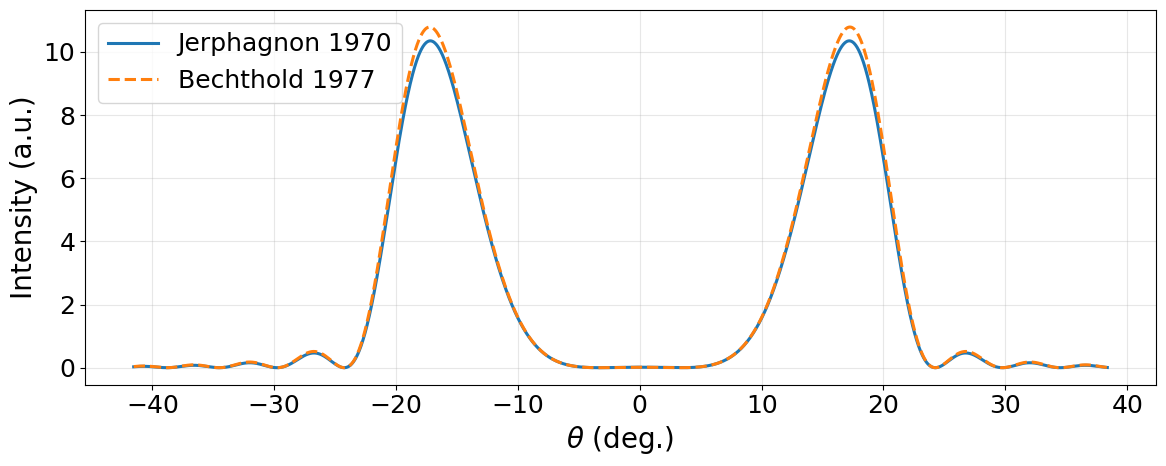

In [29]:
plt.rcParams["font.size"] = 18
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(theta_deg, jer_curve, label="Jerphagnon 1970", linewidth=2.2)
ax.plot(theta_deg, bech_curve, label="Bechthold 1977", linewidth=2.2, linestyle="--")

ax.set_xlabel(r"$\theta$ (deg.)", fontsize=20)
ax.set_ylabel("Intensity (a.u.)", fontsize=20)
ax.tick_params(axis="both", labelsize=18)
ax.grid(True, alpha=0.3)

fig.tight_layout()
ax.legend(loc="upper left", fontsize=18)
plt.show()

### Difference between theories

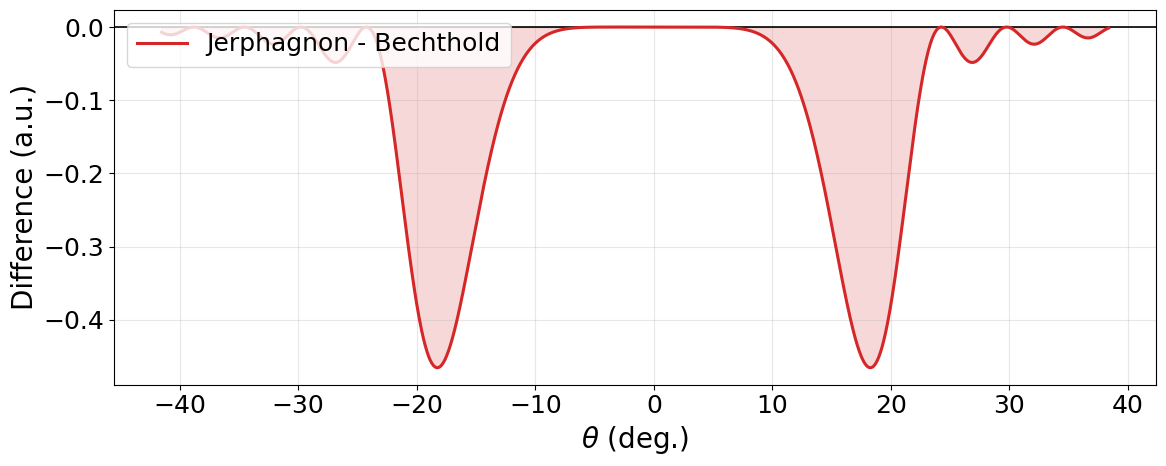

In [30]:
plt.rcParams["font.size"] = 18
fig, ax = plt.subplots(figsize=(12, 5))

ax.axhline(0.0, color="black", linewidth=1.2)
ax.plot(theta_deg, difference_curve, color="C3", linewidth=2.2, label="Jerphagnon - Bechthold")
ax.fill_between(theta_deg, 0.0, difference_curve, color="C3", alpha=0.18)

ax.set_xlabel(r"$\theta$ (deg.)", fontsize=20)
ax.set_ylabel("Difference (a.u.)", fontsize=20)
ax.tick_params(axis="both", labelsize=18)
ax.grid(True, alpha=0.3)

fig.tight_layout()
ax.legend(loc="upper left", fontsize=18)
plt.show()

### Phase comparison

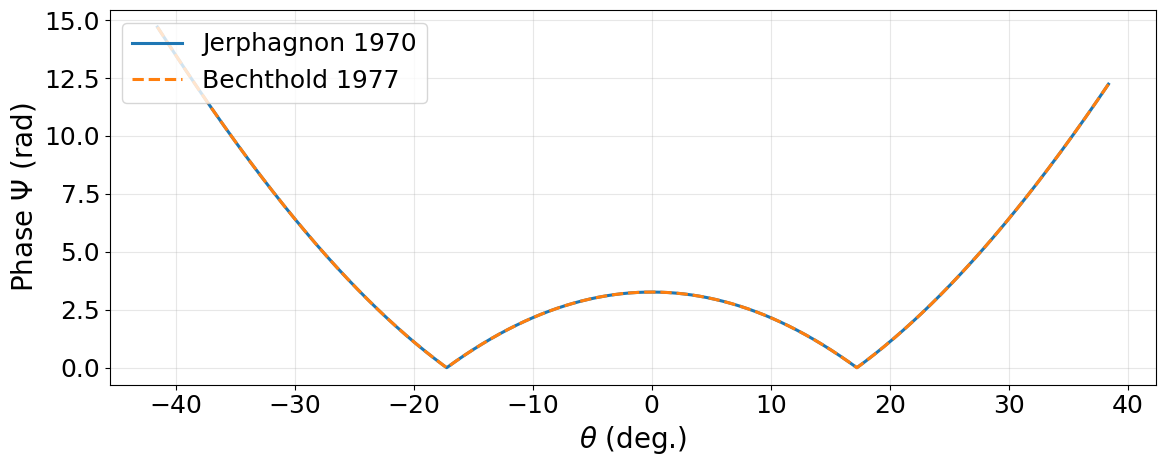

In [31]:
plt.rcParams["font.size"] = 18
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(theta_deg, jer_phase, label="Jerphagnon 1970", linewidth=2.2)
ax.plot(theta_deg, bech_phase, label="Bechthold 1977", linewidth=2.2, linestyle="--")

ax.set_xlabel(r"$\theta$ (deg.)", fontsize=20)
ax.set_ylabel(r"Phase $\Psi$ (rad)", fontsize=20)
ax.tick_params(axis="both", labelsize=18)
ax.grid(True, alpha=0.3)

fig.tight_layout()
ax.legend(loc="upper left", fontsize=18)
plt.show()

### Difference between phases

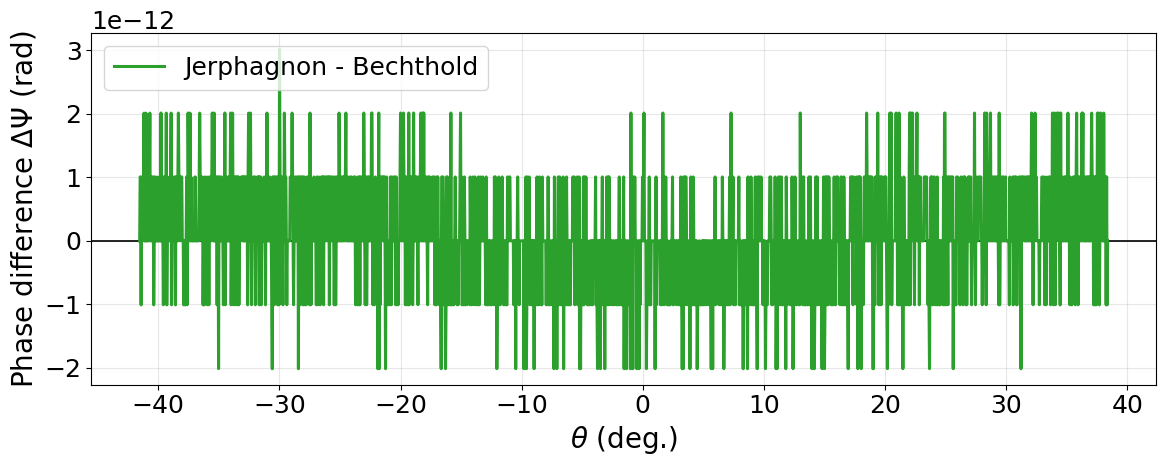

In [32]:
plt.rcParams["font.size"] = 18
fig, ax = plt.subplots(figsize=(12, 5))

ax.axhline(0.0, color="black", linewidth=1.2)
ax.plot(theta_deg, phase_difference, color="C2", linewidth=2.2, label="Jerphagnon - Bechthold")
ax.fill_between(theta_deg, 0.0, phase_difference, color="C2", alpha=0.18)

ax.set_xlabel(r"$\theta$ (deg.)", fontsize=20)
ax.set_ylabel(r"Phase difference $\Delta \Psi$ (rad)", fontsize=20)
ax.tick_params(axis="both", labelsize=18)
ax.grid(True, alpha=0.3)

fig.tight_layout()
ax.legend(loc="upper left", fontsize=18)
plt.show()